# Week 3, Day 1, Part 2 — The Same Maze, Solved a Second Way

Yesterday you built a Q-table from scratch and watched it learn the maze.
Today: **the exact same maze**, solved with a completely different method —
a Deep Q-Network, using real, professional tooling (`gymnasium`,
`stable-baselines3`).

**Why solve something you already solved?** Because this isolates exactly
one thing that's new: the *tooling*. The maze itself, the rules, the reward
— none of that changes. Tomorrow, CartPole introduces a genuinely new
*problem* on top of this same tooling. Today, only the tooling is new.

**Honest heads-up, worth saying out loud:** using DQN here is real overkill.
A Q-table already solves this perfectly, instantly, with 80 numbers. That's
the point, not an accident — this is exactly where the simple method wins,
and seeing that directly is worth more than being told it.

## 1. Recap — the same rules as yesterday

Nothing new here. Same grid, same start, same goal, same trap, same reward
function. Copied straight from Day 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

N_ROWS, N_COLS = 4, 5
N_STATES = N_ROWS * N_COLS
N_ACTIONS = 4   # 0=up, 1=down, 2=left, 3=right

START, GOAL, TRAP = (0, 0), (3, 4), (2, 2)

def to_state(row, col): return row * N_COLS + col
def to_rowcol(state): return divmod(state, N_COLS)

GOAL_STATE, TRAP_STATE, START_STATE = to_state(*GOAL), to_state(*TRAP), to_state(*START)

def take_action(state, action):
    row, col = to_rowcol(state)
    if action == 0:   row -= 1
    elif action == 1: row += 1
    elif action == 2: col -= 1
    elif action == 3: col += 1
    return to_state(np.clip(row, 0, N_ROWS-1), np.clip(col, 0, N_COLS-1))

def get_reward(state):
    if state == GOAL_STATE: return 10.0
    elif state == TRAP_STATE: return -10.0
    else: return -1.0

print('rules recapped -- identical to yesterday')

rules recapped -- identical to yesterday


## 2. What's actually new — a real `gymnasium.Env`

Yesterday's `GridWorld` class was hand-rolled, just enough to be usable.
`gymnasium.Env` is a **standard interface** — the same shape every
environment in this program follows, including tomorrow's CartPole and next
week's real market simulator. Three real differences worth noticing:

- `reset()` returns `(observation, info)` — a tuple, not just the state.
- `step()` returns **five** things: `(observation, reward, terminated,
  truncated, info)` — note `terminated` (reached a real ending, like the
  goal or the trap) is now separate from `truncated` (ran out of time,
  which isn't really "the episode's fault").
- You must **declare** `observation_space` and `action_space` up front — the
  library uses these to know what shape of data to expect, and what a
  trained agent is allowed to output.

In [2]:
class GridWorldEnv(gym.Env):
    """Same maze as Day 1, wrapped in the standard gymnasium interface so
    real RL libraries (like stable-baselines3) can train on it directly."""

    def __init__(self, max_steps=50):
        super().__init__()
        self.max_steps = max_steps
        self.observation_space = spaces.Discrete(N_STATES)   # one of 20 integers
        self.action_space = spaces.Discrete(N_ACTIONS)        # one of 4 integers

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)   # required -- sets up gymnasium's own RNG handling
        self.state = START_STATE
        self.steps = 0
        return self.state, {}       # (observation, info)

    def step(self, action):
        self.state = take_action(self.state, int(action))
        self.steps += 1
        reward = get_reward(self.state)
        terminated = self.state in (GOAL_STATE, TRAP_STATE)   # a REAL ending
        truncated = self.steps >= self.max_steps               # ran out of time
        return self.state, reward, terminated, truncated, {}

env = GridWorldEnv()
obs, info = env.reset()
print('observation_space:', env.observation_space)
print('action_space:     ', env.action_space)
print('reset() gives:', obs, info)

observation_space: Discrete(20)
action_space:      Discrete(4)
reset() gives: 0 {}


## 3. What `stable-baselines3` actually saves you from

A real DQN needs a **replay buffer** (storing past experience so the network
can learn from it repeatedly, not just once) and a **target network** (a
slow-moving copy of the network, used to keep training numerically stable).
Both are real engineering, both are easy to get subtly wrong, and neither
teaches you anything new about *reinforcement learning* once you understand
the Bellman equation from yesterday. `stable-baselines3` is a well-tested
library that handles this correctly, so you can focus on the RL concepts,
not the plumbing.

In [3]:
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

train_env = Monitor(GridWorldEnv())

model = DQN('MlpPolicy', train_env, verbose=0, seed=0,
            learning_rate=1e-3, buffer_size=5000, learning_starts=200,
            target_update_interval=100, exploration_fraction=0.3,
            exploration_final_eps=0.05)

model.learn(total_timesteps=10000)
print('training complete')

training complete


## 4. Did it find the same quality of answer?

Evaluate over several episodes, then trace the exact greedy path — same
checks as yesterday's Q-table.

In [4]:
eval_env = Monitor(GridWorldEnv())
mean_r, std_r = evaluate_policy(model, eval_env, n_eval_episodes=20, deterministic=True)
print(f'mean reward over 20 episodes: {mean_r:.2f} +/- {std_r:.2f}')
print('(std of 0.00 means every single episode found the identical, optimal-length path)')

mean reward over 20 episodes: 4.00 +/- 0.00
(std of 0.00 means every single episode found the identical, optimal-length path)


DQN path: [(0, 0), (np.int64(0), np.int64(1)), (np.int64(1), np.int64(1)), (np.int64(1), np.int64(2)), (np.int64(1), np.int64(3)), (np.int64(2), np.int64(3)), (np.int64(3), np.int64(3)), (np.int64(3), np.int64(4))]
reached goal: True | avoided trap: True


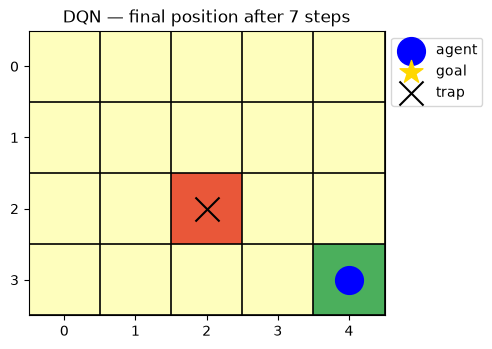

In [5]:
def render(state, title=''):
    grid = np.zeros((N_ROWS, N_COLS))
    grid[GOAL] = 2
    grid[TRAP] = -2
    r, c = to_rowcol(state)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(grid, cmap='RdYlGn', vmin=-3, vmax=3)
    ax.scatter(c, r, s=400, color='blue', marker='o', zorder=5, label='agent')
    ax.scatter(GOAL[1], GOAL[0], s=300, color='gold', marker='*', zorder=4, label='goal')
    ax.scatter(TRAP[1], TRAP[0], s=300, color='black', marker='x', zorder=4, label='trap')
    ax.set_xticks(range(N_COLS)); ax.set_yticks(range(N_ROWS))
    ax.set_xticks(np.arange(-0.5, N_COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, N_ROWS, 1), minor=True)
    ax.grid(which='minor', color='black', linewidth=1.2)
    ax.tick_params(which='minor', length=0)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax.set_title(title)
    plt.tight_layout(); plt.show()

obs, _ = eval_env.reset()
path = [to_rowcol(obs)]
for _ in range(20):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    path.append(to_rowcol(obs))
    if terminated or truncated:
        break

print('DQN path:', path)
print('reached goal:', obs == GOAL_STATE, '| avoided trap:', TRAP not in path[1:])
render(obs, f'DQN — final position after {len(path)-1} steps')

## 5. The honest comparison

Both methods reached the goal. Both avoided the trap. Both found a genuinely
optimal-length path (7 steps — the shortest possible route around the
trap). **Neither found a *better* solution than the other**, because there
isn't one to find — this maze is small enough that the optimal answer is the
ceiling for any correct method.

**What actually differed:**

| | Q-table (yesterday) | DQN (today) |
|---|---|---|
| Storage | 80 numbers, exact | A neural network, approximate |
| Training | Near-instant | Took real training time |
| Guarantee | Provably converges to optimal, on a small enough problem | No such guarantee, just empirically worked here |
| Scales to CartPole? | No — infinite states | Yes |

**The real lesson:** more machinery is not automatically better. It's
necessary exactly when the simpler tool structurally can't work — a
continuous state space, too many states to enumerate — and wasted effort
everywhere else. You now have direct, first-hand evidence of that, not just
a rule someone told you.

**Tomorrow:** a problem where the table genuinely cannot follow — and all of
today's tooling (`gymnasium.Env`, `stable-baselines3`, `terminated` vs
`truncated`) carries over unchanged.